# VAE on MNIST — Model Analysis

Loads the trained VAE from `my_models_on_mnist/`, shows training history (if available), and visualises reconstructions.

In [25]:
import os
import sys
import json

import numpy as np
import torch
import matplotlib.pyplot as plt

# Make sure the local src is on the path
ROOT = os.path.abspath(os.path.join(os.getcwd()))
sys.path.insert(0, os.path.join(ROOT, "src"))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 1. Locate the saved model

In [26]:
MODEL_BASE = os.path.join(ROOT, "my_models_on_mnist")

# Pick the most recent training run
runs = sorted(os.listdir(MODEL_BASE))
print("Available runs:", runs)

TRAINING_DIR = os.path.join(MODEL_BASE, runs[-1])
FINAL_MODEL_DIR = os.path.join(TRAINING_DIR, "final_model")
print(f"\nUsing: {FINAL_MODEL_DIR}")

Available runs: ['VAE_training_2026-04-13_22-47-03', 'VAE_training_2026-04-14_11-48-54']

Using: /Users/valentina/projects/benchmark_VAE/my_models_on_mnist/VAE_training_2026-04-14_11-48-54/final_model


## 2. Inspect model and training configuration

In [27]:
with open(os.path.join(FINAL_MODEL_DIR, "model_config.json")) as f:
    model_cfg = json.load(f)

with open(os.path.join(FINAL_MODEL_DIR, "training_config.json")) as f:
    train_cfg = json.load(f)

print("Model config:")
for k, v in model_cfg.items():
    print(f"  {k}: {v}")

print("\nTraining config:")
for k, v in train_cfg.items():
    print(f"  {k}: {v}")

Model config:
  name: VAEConfig
  input_dim: [1, 28, 28]
  latent_dim: 16
  uses_default_encoder: False
  uses_default_decoder: False
  reconstruction_loss: mse

Training config:
  name: BaseTrainerConfig
  output_dir: my_models_on_mnist
  per_device_train_batch_size: 256
  per_device_eval_batch_size: 256
  num_epochs: 100
  train_dataloader_num_workers: 0
  eval_dataloader_num_workers: 0
  optimizer_cls: Adam
  optimizer_params: None
  scheduler_cls: None
  scheduler_params: None
  learning_rate: 0.001
  steps_saving: None
  steps_predict: 100
  keep_best_on_train: False
  seed: 8
  no_cuda: False
  world_size: -1
  local_rank: -1
  rank: -1
  dist_backend: nccl
  master_addr: localhost
  master_port: 12345
  amp: False


## 3. Training history

The default `BaseTrainer` does not persist per-epoch losses to disk unless an external callback (e.g. W&B / MLflow) or a log file was configured.  
The cell below looks for a log file in the training directory; if none exists it prints an informative message.

In [ ]:
import glob as _glob

log_files = _glob.glob(os.path.join(TRAINING_DIR, "**", "*.log"), recursive=True)
json_logs  = _glob.glob(os.path.join(TRAINING_DIR, "**", "*.json"), recursive=True)

# Try to find a metrics / history JSON (not a config file)
history_file = None
for p in json_logs:
    basename = os.path.basename(p)
    if "config" not in basename and "environment" not in basename:
        history_file = p
        break

if log_files:
    print("Found log file(s):", log_files)
elif history_file:
    print("Found potential history file:", history_file)
else:
    print(
        "No training history file found.\n"
        "The BaseTrainer only persists the final model weights by default.\n"
        "To capture loss curves in future runs, add a MetricConsolePrinterCallback "
        "with a log_output_dir, or use the WandbCallback / MLflowCallback."
    )

In [ ]:
# If a log file was found, parse and plot the loss curves
if log_files:
    import re

    train_losses, eval_losses, epochs = [], [], []

    with open(log_files[0]) as f:
        for line in f:
            m_train = re.search(r"Train loss:\s*([\d\.eE+\-]+)", line)
            m_eval  = re.search(r"Eval loss:\s*([\d\.eE+\-]+)", line)
            m_epoch = re.search(r"Epoch\s+(\d+)", line)
            if m_epoch:
                epochs.append(int(m_epoch.group(1)))
            if m_train:
                train_losses.append(float(m_train.group(1)))
            if m_eval:
                eval_losses.append(float(m_eval.group(1)))

    if train_losses:
        x = range(1, len(train_losses) + 1)
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(x, train_losses, label="Train loss")
        if eval_losses:
            ax.plot(x, eval_losses, label="Eval loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title("Training history")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Log file found but no parseable loss lines detected.")
        print("First few lines of log:")
        with open(log_files[0]) as f:
            for i, line in enumerate(f):
                print(line, end="")
                if i > 10:
                    break
else:
    print("No log file — skipping loss plot.")

## 4. Load the trained model

In [30]:
from pythae.models import AutoModel

model = AutoModel.load_from_folder(FINAL_MODEL_DIR)
model = model.to(device)
model.eval()
print(model)

VAE(
  (decoder): Decoder_Conv_AE_MNIST(
    (layers): ModuleList(
      (0): Linear(in_features=16, out_features=16384, bias=True)
      (1): Sequential(
        (0): ConvTranspose2d(1024, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (2): Sequential(
        (0): ConvTranspose2d(512, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (3): Sequential(
        (0): ConvTranspose2d(256, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
        (1): Sigmoid()
      )
    )
  )
  (encoder): Encoder_Conv_VAE_MNIST(
    (layers): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(128, eps=

## 5. Load MNIST eval data

In [31]:
DATA_DIR = os.path.join(ROOT, "examples", "scripts", "data", "mnist")

eval_data = np.load(os.path.join(DATA_DIR, "eval_data.npz"))["data"] / 255.0
eval_tensor = torch.tensor(eval_data, dtype=torch.float32)

print(f"Eval data shape: {eval_tensor.shape}  range: [{eval_tensor.min():.3f}, {eval_tensor.max():.3f}]")

Eval data shape: torch.Size([10000, 1, 28, 28])  range: [0.000, 1.000]


## 6. Reconstruct sample images

Show 16 original images alongside their reconstructions.

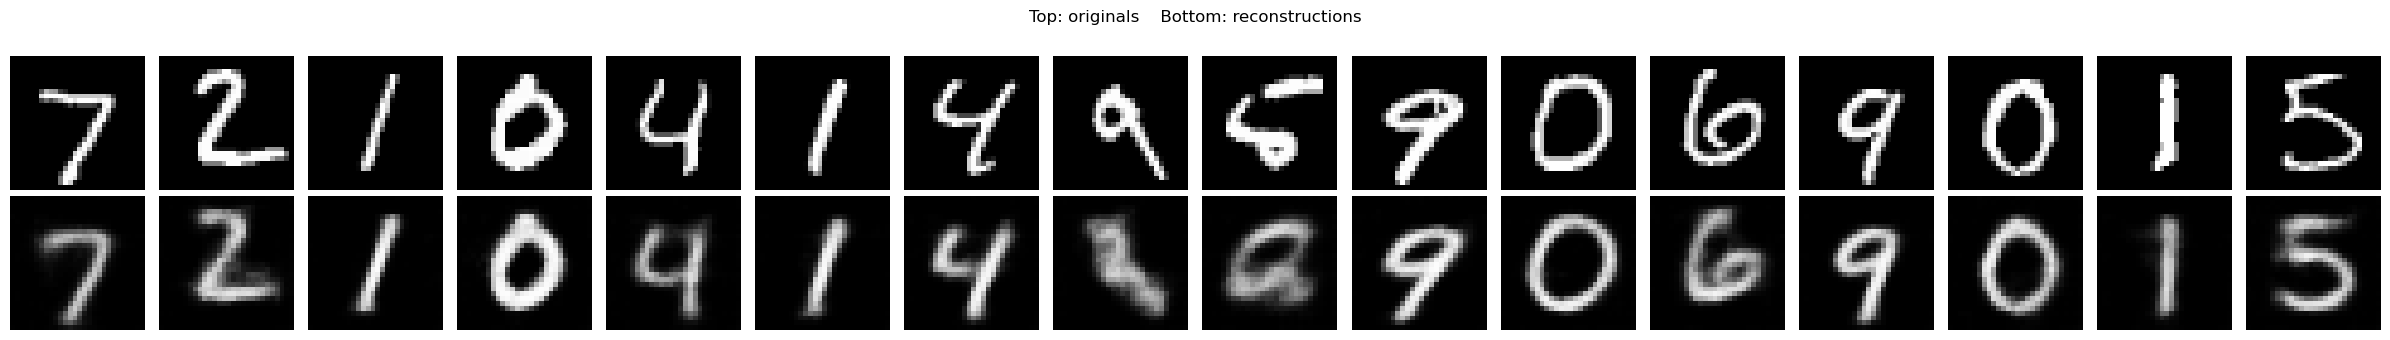

In [32]:
N = 16
samples = eval_tensor[:N].to(device)

with torch.no_grad():
    recon = model.reconstruct(samples).cpu()

samples_cpu = samples.cpu()

fig, axes = plt.subplots(nrows=2, ncols=N, figsize=(N * 1.5, 3.5))
fig.suptitle("Top: originals    Bottom: reconstructions", fontsize=12)

for j in range(N):
    axes[0, j].imshow(samples_cpu[j].squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[0, j].axis("off")
    axes[1, j].imshow(recon[j].squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[1, j].axis("off")

plt.tight_layout()
plt.show()

### Side-by-side comparison (4 examples, larger view)

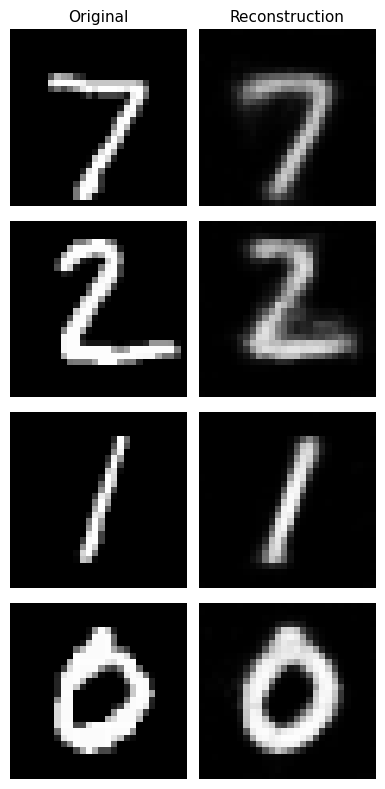

In [33]:
SHOW = 4

fig, axes = plt.subplots(nrows=SHOW, ncols=2, figsize=(4, SHOW * 2))
axes[0, 0].set_title("Original", fontsize=11)
axes[0, 1].set_title("Reconstruction", fontsize=11)

for i in range(SHOW):
    axes[i, 0].imshow(samples_cpu[i].squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(recon[i].squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 7. Reconstruction MSE on the eval set

In [34]:
BATCH = 256
total_mse = 0.0
n_batches = 0

with torch.no_grad():
    for start in range(0, len(eval_tensor), BATCH):
        batch = eval_tensor[start : start + BATCH].to(device)
        recon_batch = model.reconstruct(batch)
        total_mse += torch.mean((batch - recon_batch) ** 2).item()
        n_batches += 1

mean_mse = total_mse / n_batches
print(f"Mean reconstruction MSE on eval set: {mean_mse:.6f}")

Mean reconstruction MSE on eval set: 0.030570
